# Practical 4: Clustering

| Prac No | Practical Description 
|---|---|
| 4 (a) | Implement K-means clustering
| 4 (b) | Implement Hierarchical clustering
| 4 (c) | Implement Density-based spatial clustering of applications with noise (DBSCAN)

## Setup — imports and global configuration

In [1]:
import numpy as np, pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt, seaborn as sns, warnings
from sklearn.datasets import make_blobs, make_moons, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             adjusted_rand_score, davies_bouldin_score)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
warnings.filterwarnings('ignore')
pd.set_option('display.width', 100)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
RS = 42
np.random.seed(RS)

---
# 4(A) K-Means Clustering

### Aim
To study and implement the K-Means clustering algorithm, to determine the correct number of clusters using the elbow method and the silhouette score, and to evaluate the quality of the clusters obtained.

### Software Used
- Jupyter Notebook (Python 3)
- NumPy, Pandas
- Scikit-learn (KMeans, silhouette_score, davies_bouldin_score, adjusted_rand_score)
- Matplotlib, Seaborn

### Theory
**Clustering** is an **unsupervised** learning task. Unlike classification, the dataset has **no target column**; the algorithm has to discover the natural groups present in the data by itself, so that the samples inside one group are similar to each other and different from the samples of the other groups. It is used for customer segmentation, document grouping, image compression, anomaly detection and as a preprocessing step before a supervised model.

**K-Means** is the most widely used clustering algorithm. It divides the data into a fixed number **k** of clusters, each represented by its **centroid** (the mean of the points in that cluster). The algorithm works in four steps:

1. **Choose k** and place k initial centroids in the data space.
2. **Assignment step:** every point is given to the cluster whose centroid is nearest to it (usually by Euclidean distance).
3. **Update step:** each centroid is recomputed as the mean of all the points assigned to it.
4. **Repeat** steps 2 and 3 until the assignments stop changing, i.e. the algorithm has **converged**.

Mathematically the algorithm minimises the **Within-Cluster Sum of Squares (WCSS)**, also called **inertia**:

- **WCSS = Σ Σ ||x - μi||²**, i.e. the total squared distance of every point from the centroid of its own cluster.

Because the result depends on where the centroids are placed at the start, scikit-learn uses **k-means++** initialisation, which spreads the initial centroids far apart, and the parameter **n_init** repeats the whole process several times and keeps the best result.

The main difficulty is that **k must be given in advance**. Two methods are used to find it:

- **Elbow method:** the WCSS is plotted against k. It always falls as k rises, but the point where the fall suddenly becomes small — the "elbow" — is taken as the correct k.
- **Silhouette score:** for every point, s = (b - a)/max(a, b), where a is its average distance to the points of its own cluster and b to the points of the nearest other cluster. It lies between -1 and +1; a value near +1 means the point is well inside its cluster. The k with the highest average silhouette is chosen.

The clusters are evaluated by **internal** measures, which use only the data (silhouette score, and the **Davies-Bouldin index**, where a value near 0 is good), and by **external** measures, which compare the clusters with known labels when these happen to be available (the **Adjusted Rand Index**, where 1.0 means a perfect match and 0 means a random grouping).

The advantages of K-Means are that it is simple, fast and scales to large datasets. Its limitations are that k must be supplied, that it assumes **round (spherical) clusters of roughly equal size**, that it is sensitive to outliers because the centroid is a mean, and that feature scaling is compulsory since the algorithm is based on distance.

---
### Implementation & Result

#### Step 1: The unlabelled dataset

Shape of the dataset : (300, 2)

First five samples:
    x1     x2
-7.530  5.009
-7.931  5.474
-1.185  5.991
-5.721 -4.405
-9.109  4.851

In clustering there is NO target column. The true labels are kept only to
check the result at the end, they are never given to the algorithm.


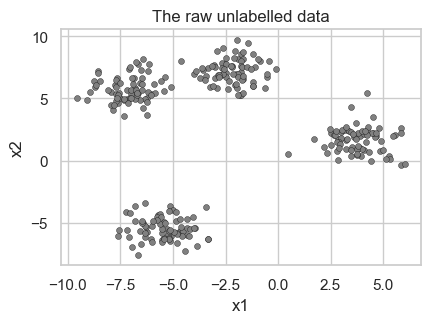

In [2]:
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=1.0,
                       center_box=(-8, 8), random_state=RS)
print('Shape of the dataset :', X.shape)
print('\nFirst five samples:')
print(pd.DataFrame(X, columns=['x1','x2']).head().round(3).to_string(index=False))
print('\nIn clustering there is NO target column. The true labels are kept only to')
print('check the result at the end, they are never given to the algorithm.')

plt.figure(figsize=(4.6, 3.4))
plt.scatter(X[:,0], X[:,1], s=18, c='gray', edgecolor='k', lw=.3)
plt.title('The raw unlabelled data'); plt.xlabel('x1'); plt.ylabel('x2')
plt.tight_layout(); plt.show()

#### Step 2: Applying K-Means and finding the centroids

Cluster label of the first ten samples : [3 3 0 1 3 1 2 1 0 2]

Coordinates of the 4 centroids:
              x1     x2
Cluster 0 -2.191  7.173
Cluster 1 -5.456 -5.454
Cluster 2  3.790  1.647
Cluster 3 -7.106  5.710

Number of points in each cluster : [76 75 75 74]
Inertia (WCSS, sum of squared distance to the centroid) : 558.530
Number of iterations taken to converge : 2


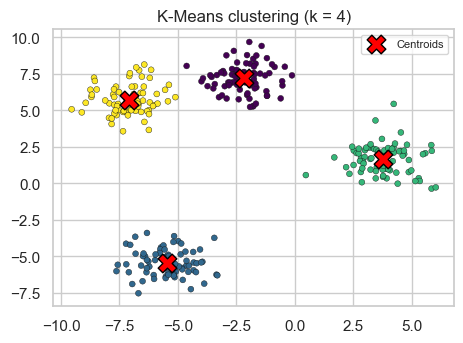

In [3]:
km = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=RS)
labels = km.fit_predict(X)

print('Cluster label of the first ten samples :', labels[:10])
print('\nCoordinates of the %d centroids:' % km.n_clusters)
print(pd.DataFrame(km.cluster_centers_, columns=['x1','x2'],
                   index=['Cluster %d' % i for i in range(4)]).round(3).to_string())
print('\nNumber of points in each cluster :', np.bincount(labels))
print('Inertia (WCSS, sum of squared distance to the centroid) : %.3f' % km.inertia_)
print('Number of iterations taken to converge :', km.n_iter_)

plt.figure(figsize=(4.8, 3.6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=18, edgecolor='k', lw=.3)
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], c='red', marker='X',
            s=180, edgecolor='black', label='Centroids')
plt.title('K-Means clustering (k = 4)'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

#### Step 3: Choosing the number of clusters - elbow method and silhouette score

 k  Inertia (WCSS)  Silhouette score
 2       6231.4279            0.5739
 3       1544.3799            0.7297
 4        558.5303            0.7418
 5        506.0955            0.6247
 6        455.1586            0.5017
 7        405.6952            0.4085
 8        356.5714            0.3406
 9        321.3594            0.3503
10        285.9323            0.3615


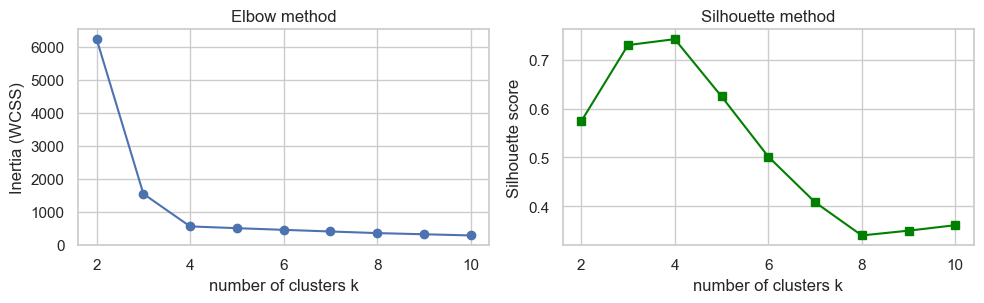


The elbow of the inertia curve is at k = 4, and the silhouette score is
highest at k = 4 (0.7418). Hence k = 4 is the correct number of clusters.


In [4]:
inertia, sil = [], []
for k in range(2, 11):
    m = KMeans(n_clusters=k, n_init=10, random_state=RS).fit(X)
    inertia.append(m.inertia_)
    sil.append(silhouette_score(X, m.labels_))

print(pd.DataFrame({'k': range(2, 11), 'Inertia (WCSS)': inertia,
                    'Silhouette score': sil}).round(4).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(range(2, 11), inertia, 'o-')
ax[0].set_xlabel('number of clusters k'); ax[0].set_ylabel('Inertia (WCSS)')
ax[0].set_title('Elbow method')
ax[1].plot(range(2, 11), sil, 's-', color='green')
ax[1].set_xlabel('number of clusters k'); ax[1].set_ylabel('Silhouette score')
ax[1].set_title('Silhouette method')
plt.tight_layout(); plt.show()

best = int(np.argmax(sil)) + 2
print('\nThe elbow of the inertia curve is at k = 4, and the silhouette score is')
print('highest at k = %d (%.4f). Hence k = 4 is the correct number of clusters.' % (best, max(sil)))

#### Step 4: Evaluating the clusters and the limitation of K-Means

Evaluation of the K-Means result (k = 4):
   Silhouette score      : 0.7418  (near +1 is good)
   Davies-Bouldin index  : 0.3614  (near 0 is good)
   Adjusted Rand Index   : 0.9911  (compared with the true labels)

Cluster label against the true group:
Cluster      0   1   2   3
True group                
0           75   0   0   0
1            0   0  75   0
2            0  75   0   0
3            1   0   0  74

On the two-moons data K-Means gives ARI = 0.2475 only, because it can draw
only straight boundaries and assumes round (spherical) clusters.


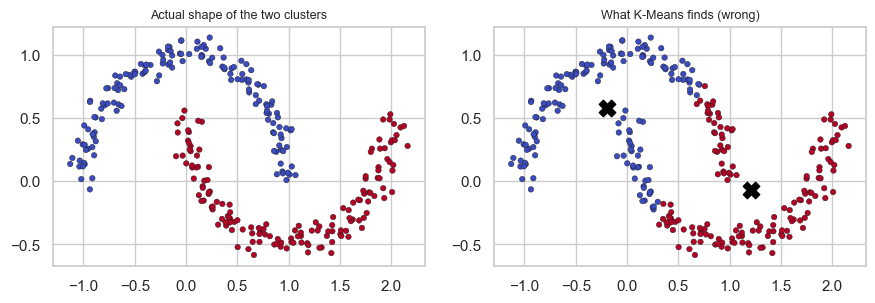

In [5]:
print('Evaluation of the K-Means result (k = 4):')
print('   Silhouette score      : %.4f  (near +1 is good)' % silhouette_score(X, labels))
print('   Davies-Bouldin index  : %.4f  (near 0 is good)' % davies_bouldin_score(X, labels))
print('   Adjusted Rand Index   : %.4f  (compared with the true labels)'
      % adjusted_rand_score(y_true, labels))
print('\nCluster label against the true group:')
print(pd.crosstab(y_true, labels, rownames=['True group'], colnames=['Cluster']).to_string())

# --- limitation : K-Means assumes round clusters of similar size ---
Xm, ym = make_moons(n_samples=300, noise=.06, random_state=RS)
km_moon = KMeans(n_clusters=2, n_init=10, random_state=RS).fit(Xm)
print('\nOn the two-moons data K-Means gives ARI = %.4f only, because it can draw'
      % adjusted_rand_score(ym, km_moon.labels_))
print('only straight boundaries and assumes round (spherical) clusters.')

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].scatter(Xm[:,0], Xm[:,1], c=ym, cmap='coolwarm', s=16, edgecolor='k', lw=.3)
ax[0].set_title('Actual shape of the two clusters', fontsize=9)
ax[1].scatter(Xm[:,0], Xm[:,1], c=km_moon.labels_, cmap='coolwarm', s=16, edgecolor='k', lw=.3)
ax[1].scatter(km_moon.cluster_centers_[:,0], km_moon.cluster_centers_[:,1], c='black',
              marker='X', s=140)
ax[1].set_title('What K-Means finds (wrong)', fontsize=9)
plt.tight_layout(); plt.show()

### Observations
- The dataset had **300 samples and 2 features with no target column**, and the true group of each point was kept aside only to verify the result at the end.
- K-Means with k = 4 converged in just **2 iterations**, produced clusters of **76, 75, 75 and 74 points**, and gave a final **inertia (WCSS) of 558.530**.
- In the elbow curve the WCSS fell steeply from **6231.43 at k = 2 to 1544.38 at k = 3 and 558.53 at k = 4**, but then only to 506.10 at k = 5. The bend at **k = 4** is therefore the elbow.
- The **silhouette score was also highest at k = 4 (0.7418)** against 0.7297 at k = 3 and 0.6247 at k = 5, so both methods agreed on k = 4.
- The final clusters scored a **silhouette of 0.7418, a Davies-Bouldin index of 0.3614 and an Adjusted Rand Index of 0.9911**, and the cross-tabulation showed that **only 1 of the 300 points** was placed in the wrong group.
- On the **two-moons data K-Means gave an ARI of only 0.2475**, because it can draw only straight boundaries around round clusters and therefore cut both the crescents in half.

### Conclusion

In conclusion, the K-Means clustering algorithm was successfully implemented on an unlabelled dataset and the natural groups present in the data were recovered without using any target column. It was observed that the algorithm works by repeating the assignment and update steps until the centroids stop moving, and that it minimises the within-cluster sum of squares. The correct number of clusters was determined by the elbow method and confirmed independently by the silhouette score, both of which pointed to k = 4, and the quality of the result was verified by the silhouette score, the Davies-Bouldin index and the Adjusted Rand Index. It was also observed that K-Means assumes round clusters of similar size, and that it therefore fails completely on clusters having a curved shape.

---
# 4(B) Hierarchical Clustering

### Aim
To study and implement hierarchical (agglomerative) clustering, to construct and read a dendrogram, to compare the different linkage criteria and to evaluate the clusters obtained.

### Software Used
- Jupyter Notebook (Python 3)
- NumPy, Pandas
- Scikit-learn (AgglomerativeClustering), SciPy (linkage, dendrogram, fcluster)
- Matplotlib, Seaborn

### Theory
**Hierarchical clustering** builds a complete **hierarchy (tree) of clusters** instead of a single flat partition. Its great advantage is that the number of clusters need **not** be given in advance; it is read afterwards from the tree. There are two approaches:

- **Agglomerative (bottom-up):** every point starts as its own cluster, and the two closest clusters are merged repeatedly until only one cluster is left. This is the approach used in practice.
- **Divisive (top-down):** all the points start in one cluster which is split repeatedly. It is far more expensive and is rarely used.

The agglomerative algorithm works as follows:

1. Treat each of the n points as a separate cluster and compute the **proximity (distance) matrix** between every pair.
2. Find the **two closest clusters** and merge them into one.
3. **Update** the distance matrix for the new cluster.
4. Repeat steps 2 and 3 until a single cluster remains, recording the distance at which every merge took place.

The distance between two *clusters* (not two points) is defined by the **linkage criterion**, and the result changes completely with it:

- **Single linkage:** the distance between the two **nearest** members. It can find long, thin shapes but suffers from the **chaining effect**, where two clusters get joined through a line of intermediate points.
- **Complete linkage:** the distance between the two **farthest** members. It produces compact clusters of similar diameter and is less affected by chaining.
- **Average linkage:** the average distance between all the pairs of members, i.e. a compromise between the two above.
- **Ward's linkage:** merges the pair of clusters that increases the **total within-cluster variance** the least. It is the default choice and usually gives the most balanced clusters.

The result is drawn as a **dendrogram**, a tree in which the **height of each horizontal link is the distance at which those two clusters were merged**. To obtain a flat clustering, the dendrogram is **cut by a horizontal line**: the number of vertical lines it crosses is the number of clusters. The line is normally drawn across the **tallest vertical gap**, because a tall link means that two very dissimilar groups were merged there.

The advantages of hierarchical clustering are that k is not needed beforehand, that the dendrogram shows the whole structure of the data at every level, and that the result is deterministic (there is no random initialisation as in K-Means). Its disadvantages are that the time complexity is about **O(n³)** and the memory **O(n²)**, so it is suitable only for small and medium datasets, and that a merge once made can **never be undone**, so an early mistake is carried to the end.

---
### Implementation & Result

#### Step 1: The distance (proximity) matrix

In [6]:
small = np.array([[1,1],[1.5,1.5],[5,5],[5.5,5.2],[9,1],[9.5,1.5]])
names = ['P1','P2','P3','P4','P5','P6']
print('Six sample points:')
print(pd.DataFrame(small, columns=['x1','x2'], index=names).to_string())

d = squareform(pdist(small))
print('\nEuclidean distance matrix:')
print(pd.DataFrame(d, index=names, columns=names).round(2).to_string())
i, j = np.unravel_index(np.argmin(d + np.eye(len(d))*99), d.shape)
print('\nThe smallest distance is between %s and %s (%.3f), so they are merged first.'
      % (names[i], names[j], d[i, j]))
print('Agglomerative clustering repeats this merging until one cluster is left.')

Six sample points:
     x1   x2
P1  1.0  1.0
P2  1.5  1.5
P3  5.0  5.0
P4  5.5  5.2
P5  9.0  1.0
P6  9.5  1.5

Euclidean distance matrix:
      P1    P2    P3    P4    P5    P6
P1  0.00  0.71  5.66  6.16  8.00  8.51
P2  0.71  0.00  4.95  5.45  7.52  8.00
P3  5.66  4.95  0.00  0.54  5.66  5.70
P4  6.16  5.45  0.54  0.00  5.47  5.45
P5  8.00  7.52  5.66  5.47  0.00  0.71
P6  8.51  8.00  5.70  5.45  0.71  0.00

The smallest distance is between P3 and P4 (0.539), so they are merged first.
Agglomerative clustering repeats this merging until one cluster is left.


#### Step 2: The linkage matrix and the dendrogram

The linkage matrix (each row is one merge):
   Cluster A  Cluster B  Distance  No. of points
0        2.0        3.0     0.539            2.0
1        0.0        1.0     0.707            2.0
2        4.0        5.0     0.707            2.0
3        6.0        7.0     7.851            4.0
4        8.0        9.0    10.290            6.0

Row 1 merged points 0 and 1 (P1, P2) at a distance of 0.539.
New clusters are numbered from 6 onwards (n = 6 original points).


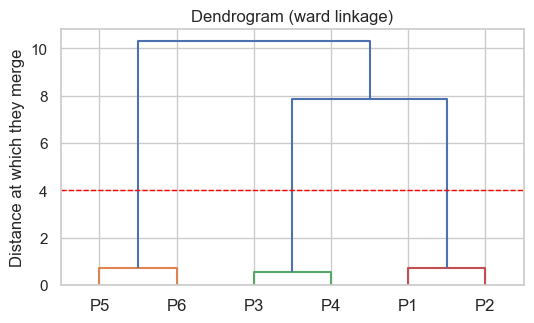

Cutting the dendrogram at the red line (distance = 4) gives the clusters :
    [3 3 2 2 1 1]
i.e. (P1,P2), (P3,P4) and (P5,P6) -> three clusters.


In [7]:
Z = linkage(small, method='ward')
print('The linkage matrix (each row is one merge):')
print(pd.DataFrame(Z, columns=['Cluster A','Cluster B','Distance','No. of points'])
        .round(3).to_string())
print('\nRow 1 merged points 0 and 1 (P1, P2) at a distance of %.3f.' % Z[0,2])
print('New clusters are numbered from 6 onwards (n = 6 original points).')

plt.figure(figsize=(5.5, 3.4))
dendrogram(Z, labels=names)
plt.axhline(4, color='red', ls='--', lw=1)
plt.title('Dendrogram (ward linkage)'); plt.ylabel('Distance at which they merge')
plt.tight_layout(); plt.show()

print('Cutting the dendrogram at the red line (distance = 4) gives the clusters :')
print('   ', fcluster(Z, t=4, criterion='distance'))
print('i.e. (P1,P2), (P3,P4) and (P5,P6) -> three clusters.')

#### Step 3: Hierarchical clustering of the full dataset

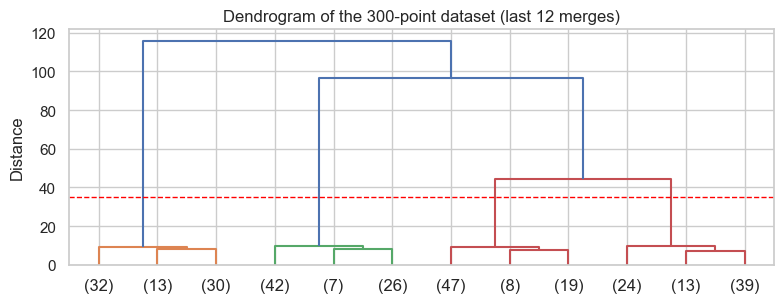

The largest vertical jump is crossed by the red line, and it is crossed
4 times, so the dataset has 4 clusters.

Number of points in each cluster : [75 75 76 74]
Silhouette score    : 0.7418
Adjusted Rand Index : 0.9911


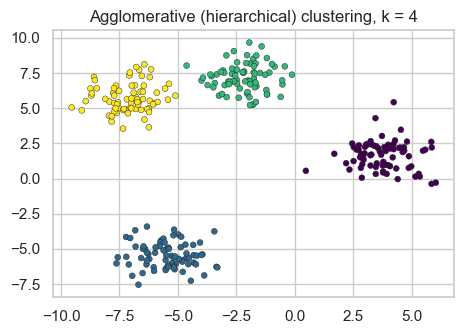

In [8]:
Z_full = linkage(X, method='ward')
plt.figure(figsize=(8, 3.2))
dendrogram(Z_full, truncate_mode='lastp', p=12, show_leaf_counts=True)
plt.axhline(35, color='red', ls='--', lw=1)
plt.title('Dendrogram of the 300-point dataset (last 12 merges)')
plt.ylabel('Distance'); plt.tight_layout(); plt.show()

print('The largest vertical jump is crossed by the red line, and it is crossed')
print('4 times, so the dataset has 4 clusters.\n')

hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
h_labels = hc.fit_predict(X)
print('Number of points in each cluster :', np.bincount(h_labels))
print('Silhouette score    : %.4f' % silhouette_score(X, h_labels))
print('Adjusted Rand Index : %.4f' % adjusted_rand_score(y_true, h_labels))

plt.figure(figsize=(4.8, 3.5))
plt.scatter(X[:,0], X[:,1], c=h_labels, cmap='viridis', s=18, edgecolor='k', lw=.3)
plt.title('Agglomerative (hierarchical) clustering, k = 4')
plt.tight_layout(); plt.show()

#### Step 4: Comparing the linkage methods and K-Means

In [9]:
print('Comparison of the four linkage methods:\n')
rows = []
for link in ['ward', 'complete', 'average', 'single']:
    m = AgglomerativeClustering(n_clusters=4, linkage=link).fit(X)
    rows.append([link, silhouette_score(X, m.labels_),
                 adjusted_rand_score(y_true, m.labels_), str(np.bincount(m.labels_))])
print(pd.DataFrame(rows, columns=['Linkage','Silhouette','Adjusted Rand Index',
                                  'Cluster sizes']).round(4).to_string(index=False))

print('\n   ward     : merges the pair which increases the total variance the least')
print('   complete : uses the distance between the two FARTHEST points')
print('   average  : uses the average distance between all the pairs')
print('   single   : uses the distance between the two NEAREST points (causes chaining)')

print('\nHierarchical clustering compared with K-Means on the same data:')
print('   K-Means       silhouette %.4f   ARI %.4f'
      % (silhouette_score(X, labels), adjusted_rand_score(y_true, labels)))
print('   Hierarchical  silhouette %.4f   ARI %.4f'
      % (silhouette_score(X, h_labels), adjusted_rand_score(y_true, h_labels)))
print('\nHierarchical clustering does not need k in advance (it is read from the')
print('dendrogram) but it is slower, about O(n^3), so it suits small datasets.')

Comparison of the four linkage methods:

 Linkage  Silhouette  Adjusted Rand Index     Cluster sizes
    ward      0.7418               0.9911     [75 75 76 74]
complete      0.7398               0.9823     [75 75 75 75]
 average      0.7398               0.9823     [75 75 75 75]
  single      0.6024               0.7079 [150  74   1  75]

   ward     : merges the pair which increases the total variance the least
   complete : uses the distance between the two FARTHEST points
   average  : uses the average distance between all the pairs
   single   : uses the distance between the two NEAREST points (causes chaining)

Hierarchical clustering compared with K-Means on the same data:
   K-Means       silhouette 0.7418   ARI 0.9911
   Hierarchical  silhouette 0.7418   ARI 0.9911

Hierarchical clustering does not need k in advance (it is read from the
dendrogram) but it is slower, about O(n^3), so it suits small datasets.


### Observations
- In the distance matrix of the six sample points the smallest value was **0.539 between P3 and P4**, so these two were merged first, which is exactly what the first row of the linkage matrix shows.
- The linkage matrix recorded the merges at the distances **0.539, 0.707, 0.707, 7.851 and 10.290**. The first three are very small (points joining inside a group) while the fourth is a sudden jump to 7.851, which means that two genuinely different groups were merged there.
- Cutting the dendrogram at a distance of 4 crossed **three vertical lines** and gave the clusters **(P1, P2), (P3, P4) and (P5, P6)**, which matches the actual arrangement of the six points.
- On the 300-point dataset the dendrogram showed the same behaviour, and cutting it below the tallest jump gave **4 clusters of 75, 75, 76 and 74 points** with a **silhouette of 0.7418** and an **Adjusted Rand Index of 0.9911**.
- Among the linkage methods, **ward gave the best result (silhouette 0.7418, ARI 0.9911)**, complete and average were close behind (0.7398, 0.9823), while **single linkage failed badly (silhouette 0.6024, ARI 0.7079)** and produced very unequal clusters of **150, 75, 74 and 1 points** because of the chaining effect.
- Hierarchical clustering and K-Means gave **exactly the same score on this dataset (silhouette 0.7418, ARI 0.9911)**, but hierarchical clustering did not need the value of k beforehand, though it is far slower at about O(n³).

### Conclusion

In conclusion, hierarchical (agglomerative) clustering was successfully implemented, the proximity matrix and the linkage matrix were examined step by step, and the dendrogram was plotted and cut to obtain the final clusters. It was observed that the main advantage of this method is that the number of clusters need not be decided in advance, since it can be read from the tallest vertical gap of the dendrogram, and that the result is deterministic because there is no random initialisation. The comparison of the linkage criteria showed that the choice of linkage changes the result completely, with Ward's method giving the most balanced clusters and single linkage failing because of the chaining effect. It was also observed that hierarchical clustering matched the accuracy of K-Means on this dataset but is much more expensive in time and memory, so it is suited to small datasets.

---
# 4(C) DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

### Aim
To study and implement the DBSCAN algorithm, to understand the parameters eps and min_samples, to detect noise points, and to compare DBSCAN with K-Means and hierarchical clustering on clusters of different shapes.

### Software Used
- Jupyter Notebook (Python 3)
- NumPy, Pandas
- Scikit-learn (DBSCAN, NearestNeighbors, adjusted_rand_score)
- Matplotlib, Seaborn

### Theory
**DBSCAN** groups the points that lie close together in a **dense** region and marks the points that lie alone in a low-density region as **noise**. Because a cluster is grown point by point wherever the density is high, a cluster can take **any shape**, and unlike K-Means the number of clusters need **not** be given in advance.

DBSCAN uses only two parameters:

- **eps (ε):** the radius of the neighbourhood around a point.
- **min_samples (MinPts):** the minimum number of points that must lie inside that radius for the region to be called dense.

Using these, every point of the dataset becomes one of three kinds:

- **Core point:** a point having at least min_samples points (including itself) within the distance eps. It lies in the interior of a cluster.
- **Border point:** a point that has fewer than min_samples neighbours, but which lies inside the eps radius of some core point. It lies at the edge of a cluster.
- **Noise point (outlier):** a point that is neither a core point nor a border point. Scikit-learn gives it the label **-1**.

Two further definitions complete the algorithm. A point q is **directly density-reachable** from a core point p if q lies within eps of p, and two points are **density-connected** if there is a chain of core points joining them. A cluster is then simply a maximal set of density-connected points.

The algorithm therefore works as follows:

1. Pick an unvisited point and find all the points within its eps neighbourhood.
2. If the number of neighbours is at least min_samples, the point is a **core point** and a new cluster is started with it.
3. The cluster is **expanded** by adding every point that is density-reachable from the core points already in it.
4. If the point is not a core point it is temporarily labelled as **noise** (it may later become a border point of some cluster).
5. Repeat until every point has been visited.

The choice of the parameters is important. **min_samples** is usually taken as at least D + 1, or 2×D, where D is the number of features. **eps** is then found from the **k-distance graph**: the distance of every point to its k-th nearest neighbour is sorted and plotted, and the value of eps is taken at the **elbow** of that curve, where the distance suddenly begins to rise.

The advantages of DBSCAN are that it discovers clusters of **arbitrary shape**, that it needs no value of k, and that it **detects outliers automatically**, which K-Means and hierarchical clustering cannot do since they force every point into some cluster. Its disadvantages are that it fails when different clusters have **very different densities** (a single eps cannot suit all of them), that it becomes weak in high dimensions because of the curse of dimensionality, and that the result is quite sensitive to the values chosen for eps and min_samples.

---
### Implementation & Result

#### Step 1: Applying DBSCAN and detecting the noise points

Clusters found  : 2
Noise points    : 8
Core points     : 294
Border points   : 10

Labels of the first fifteen samples : [0 0 0 1 0 0 0 1 1 0 0 1 0 1 0]
(the label -1 means the point is noise / an outlier)

Outlier points that were correctly marked as noise : 8 of 12
Adjusted Rand Index on the 300 moon points : 1.0000


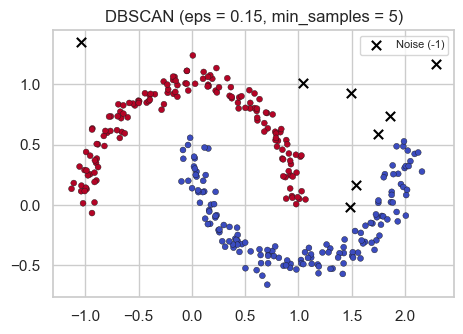

In [10]:
# twelve random outlier points are added to the moons data
rng = np.random.default_rng(RS)
outliers = rng.uniform([-1.4, -0.8], [2.4, 1.4], size=(12, 2))
Xn = np.vstack([Xm, outliers])

db = DBSCAN(eps=0.15, min_samples=5).fit(Xn)
lab = db.labels_

n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
n_noise = list(lab).count(-1)
print('Clusters found  :', n_clusters)
print('Noise points    :', n_noise)
print('Core points     :', len(db.core_sample_indices_))
print('Border points   :', len(lab) - len(db.core_sample_indices_) - n_noise)
print('\nLabels of the first fifteen samples :', lab[:15])
print('(the label -1 means the point is noise / an outlier)')
print('\nOutlier points that were correctly marked as noise : %d of 12'
      % (lab[300:] == -1).sum())
print('Adjusted Rand Index on the 300 moon points : %.4f'
      % adjusted_rand_score(ym, lab[:300]))

plt.figure(figsize=(4.8, 3.5))
plt.scatter(Xn[lab!=-1, 0], Xn[lab!=-1, 1], c=lab[lab!=-1], cmap='coolwarm', s=18,
            edgecolor='k', lw=.3)
plt.scatter(Xn[lab==-1, 0], Xn[lab==-1, 1], c='black', marker='x', s=45, label='Noise (-1)')
plt.legend(fontsize=8)
plt.title('DBSCAN (eps = 0.15, min_samples = 5)')
plt.tight_layout(); plt.show()

#### Step 2: Choosing eps using the k-distance graph

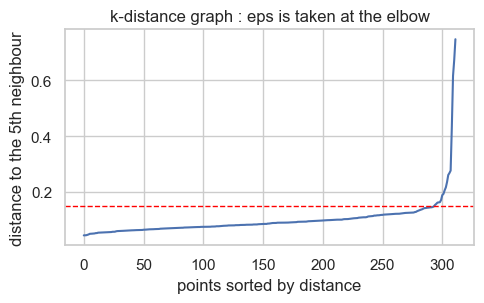

Distance to the 5th nearest neighbour: minimum 0.0431, median 0.0858, maximum 0.7482
The curve rises sharply after about 0.15 (the elbow), therefore eps = 0.15
was chosen. The few points above the line are the outliers.


In [11]:
# --- the k-distance graph is used to choose eps ---
nn = NearestNeighbors(n_neighbors=5).fit(Xn)
dist, _ = nn.kneighbors(Xn)
kdist = np.sort(dist[:, -1])

plt.figure(figsize=(5, 3.2))
plt.plot(kdist)
plt.axhline(0.15, color='red', ls='--', lw=1)
plt.xlabel('points sorted by distance'); plt.ylabel('distance to the 5th neighbour')
plt.title('k-distance graph : eps is taken at the elbow')
plt.tight_layout(); plt.show()

print('Distance to the 5th nearest neighbour: minimum %.4f, median %.4f, maximum %.4f'
      % (kdist.min(), np.median(kdist), kdist.max()))
print('The curve rises sharply after about 0.15 (the elbow), therefore eps = 0.15')
print('was chosen. The few points above the line are the outliers.')

#### Step 3: The effect of eps and min_samples

In [12]:
print('Effect of eps and min_samples:\n')
rows = []
for eps in [0.05, 0.10, 0.15, 0.40]:
    for ms in [5, 10]:
        m = DBSCAN(eps=eps, min_samples=ms).fit(Xn)
        k = len(set(m.labels_)) - (1 if -1 in m.labels_ else 0)
        rows.append([eps, ms, k, list(m.labels_).count(-1),
                     adjusted_rand_score(ym, m.labels_[:300])])
print(pd.DataFrame(rows, columns=['eps','min_samples','Clusters found','Noise points',
                                  'Adjusted Rand Index']).round(4).to_string(index=False))
print('\nA very small eps makes almost every point noise, and a very large eps joins')
print('all the points into one single cluster. min_samples decides how many points')
print('are needed inside the eps radius for a point to become a CORE point.')

Effect of eps and min_samples:

 eps  min_samples  Clusters found  Noise points  Adjusted Rand Index
0.05            5               6           277               0.0071
0.05           10               0           312               0.0000
0.10            5              13            36               0.1639
0.10           10               5           252               0.0377
0.15            5               2             8               1.0000
0.15           10               3            14               0.9231
0.40            5               1             3               0.0000
0.40           10               1             3               0.0000

A very small eps makes almost every point noise, and a very large eps joins
all the points into one single cluster. min_samples decides how many points
are needed inside the eps radius for a point to become a CORE point.


#### Step 4: Comparison of K-Means, hierarchical clustering and DBSCAN

In [13]:
print('The three algorithms on the same two datasets:\n')
rows = []
for name, data, truth in [('Blobs (round)', X, y_true), ('Moons (curved)', Xm, ym)]:
    e = 1.0 if name.startswith('Blobs') else 0.15
    for alg, model in [('K-Means', KMeans(n_clusters=2 if 'Moons' in name else 4,
                                          n_init=10, random_state=RS)),
                       ('Hierarchical', AgglomerativeClustering(
                            n_clusters=2 if 'Moons' in name else 4)),
                       ('DBSCAN', DBSCAN(eps=e, min_samples=5))]:
        lb = model.fit_predict(data)
        k = len(set(lb)) - (1 if -1 in lb else 0)
        rows.append([name, alg, k, adjusted_rand_score(truth, lb)])
print(pd.DataFrame(rows, columns=['Dataset','Algorithm','Clusters found',
                                  'Adjusted Rand Index']).round(4).to_string(index=False))

print('\nOn round, well separated clusters all the three work well.')
print('On the curved clusters only DBSCAN gives the correct answer, because it')
print('grows a cluster by density and does not assume any shape.')
print('\nDBSCAN also marks outliers as -1, which K-Means and hierarchical cannot do.')

The three algorithms on the same two datasets:

       Dataset    Algorithm  Clusters found  Adjusted Rand Index
 Blobs (round)      K-Means               4               0.9911
 Blobs (round) Hierarchical               4               0.9911
 Blobs (round)       DBSCAN               4               0.9639
Moons (curved)      K-Means               2               0.2475
Moons (curved) Hierarchical               2               0.5968
Moons (curved)       DBSCAN               2               1.0000

On round, well separated clusters all the three work well.
On the curved clusters only DBSCAN gives the correct answer, because it
grows a cluster by density and does not assume any shape.

DBSCAN also marks outliers as -1, which K-Means and hierarchical cannot do.


### Observations
- On the two-moons data with twelve outliers added, DBSCAN with **eps = 0.15 and min_samples = 5** found **exactly 2 clusters**, and classified the points into **294 core points, 10 border points and 8 noise points**.
- **8 of the 12 artificial outliers were correctly marked as noise (label -1)**, and the **Adjusted Rand Index on the 300 moon points was a perfect 1.0000**, i.e. the two crescents were recovered exactly, which K-Means could not do.
- In the **k-distance graph** the distance to the 5th nearest neighbour had a minimum of **0.0431 and a median of 0.0858** but rose to a maximum of **0.7482**; the curve bends near **0.15**, which is why that value was taken as eps, and the points above the line were precisely the outliers.
- The parameter study showed both failure modes clearly: with **eps = 0.05, 277 of the 312 points became noise** and 6 meaningless clusters were formed (ARI 0.0071), while with **eps = 0.40 everything collapsed into a single cluster** (ARI 0.0000). The correct answer was obtained only at **eps = 0.15 (ARI 1.0000)**.
- Raising min_samples from 5 to 10 at eps = 0.15 broke the data into **3 clusters with 14 noise points** (ARI 0.9231), which shows that a larger min_samples makes the definition of density stricter.
- In the final comparison, all three algorithms worked well on the round blobs (**K-Means 0.9911, hierarchical 0.9911, DBSCAN 0.9639**), but on the curved moons **K-Means gave only 0.2475 and hierarchical 0.5968, while DBSCAN gave 1.0000**, because it grows a cluster by density and assumes no shape at all.

### Conclusion

In conclusion, the DBSCAN algorithm was successfully implemented and its behaviour was studied in detail. It was observed that DBSCAN groups the points by density rather than by distance to a centre, so it is able to discover clusters of any shape, and that it separates the points into core, border and noise points, thereby detecting the outliers automatically as label -1 — something neither K-Means nor hierarchical clustering can do. It was also observed that the result depends entirely on the two parameters: a very small eps turns almost every point into noise while a very large eps merges everything into a single cluster, and that a suitable value is best obtained from the elbow of the k-distance graph. Finally, the comparison of the three algorithms showed that all of them work on round, well-separated clusters, but only DBSCAN recovers clusters that are curved or of irregular shape.